In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/tickers.db")

with open("../sql/event_window.sql") as f:
    query1 = f.read()
event_window = pd.read_sql_query(query1, conn)

with open("../sql/excess_return.sql") as f:
    query2 = f.read()
excess = pd.read_sql_query(query2, conn)

In [2]:
print("event_window shape:", event_window.shape)
print(event_window.head())
print(event_window.dtypes)

event_window shape: (59, 8)
  event_id  ticker  event_date  \
0      E00  000660  2025-01-31   
1     E00a  000660  2025-04-24   
2     E00b  000660  2025-07-24   
3      E11  000660  2025-09-03   
4      E12  000660  2025-10-02   

                                   event_description         event_type  \
0  SK Hynix shares tumble as trading resumes afte...  market_volatility   
1  SK Hynix posts second-highest quarterly result...           earnings   
2  SK Hynix posts all-time-high quarterly revenue...           earnings   
3  US revoked SK Hynix's Validated End User waive...  market_volatility   
4  SK Hynix surged nearly 10% to an all-time high...   corporate_action   

   price_on_event_day  price_3days_before  price_3days_after  
0            199200.0                 NaN           262500.0  
1            178300.0                 NaN           395500.0  
2            269500.0                 NaN           558000.0  
3            262500.0            199200.0           841000.0  
4

In [3]:
print("excess return :", excess.shape)
print(excess.head())
print(excess.dtypes)

excess return : (1148, 6)
         date  ticker  stock_return  benchmark_return benchmark_ticker  \
0  2025-01-02  000660           NaN               NaN            KOSPI   
1  2025-01-03  000660      6.250000          1.791625            KOSPI   
2  2025-01-06  000660      9.840572          1.913249            KOSPI   
3  2025-01-07  000660     -2.402402          0.139032            KOSPI   
4  2025-01-08  000660     -0.153846          1.161671            KOSPI   

   excess_return  
0            NaN  
1       4.458375  
2       7.927323  
3      -2.541434  
4      -1.315517  
date                 object
ticker               object
stock_return        float64
benchmark_return    float64
benchmark_ticker     object
excess_return       float64
dtype: object


In [4]:
def get_excess_return_window(row, window=3):
    ticker_data = excess[excess['ticker'] == row['ticker']].reset_index(drop=True)
    idx = ticker_data[ticker_data['date'] == row['event_date']].index   # 'date'로 수정
    if len(idx) == 0:
        return None
    i = idx[0]
    window_data = ticker_data.iloc[max(0, i-window):i+window+1]
    return window_data['excess_return'].sum()

event_window['cumulative_excess_return'] = event_window.apply(get_excess_return_window, axis=1)

In [5]:
summary = event_window.groupby(['ticker', 'event_type'])['cumulative_excess_return'].agg(['mean', 'std', 'count'])
summary

mean        std  count
ticker event_type                                   
000660 corporate_action   8.372638   6.974602      4
       earnings           6.400469   8.451164      5
       foreign_flow       5.511359   1.647684      2
       market_volatility  3.348305  10.447354      7
005930 corporate_action   5.847693   2.934538      9
       earnings           3.793282   2.617486      6
       foreign_flow      -1.059226        NaN      1
       market_volatility  2.676884   3.843496      8
MU     corporate_action  -1.161791  23.329512      5
       earnings           0.228845   6.406801      6
       market_volatility  9.561655   7.888475      6

In [6]:
event_window.to_csv("../data/processed/event_window_multi.csv", index=False)
summary.to_csv("../data/processed/ticker_event_summary.csv")

In [7]:
from scipy import stats

def run_ttest(group):
    values = group['cumulative_excess_return'].dropna()
    if len(values) < 2:
        return pd.Series({'t_stat': None, 'p_value': None, 'n': len(values)})
    t_stat, p_value = stats.ttest_1samp(values, 0)
    return pd.Series({'t_stat': t_stat, 'p_value': p_value, 'n': len(values)})

ttest_results = event_window.groupby(['ticker', 'event_type']).apply(run_ttest)
ttest_results

/var/folders/zc/pxflczyx7d5bbcglr4zj3vxh0000gn/T/ipykernel_41289/2251543970.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy import stats
/var/folders/zc/pxflczyx7d5bbcglr4zj3vxh0000gn/T/ipykernel_41289/2251543970.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ttest_results = event_window.groupby(['ticker', 'event_type']).apply(run_ttest)


t_stat   p_value    n
ticker event_type                                
000660 corporate_action   2.400893  0.095797  4.0
       earnings           1.693481  0.165616  5.0
       foreign_flow       4.730420  0.132627  2.0
       market_volatility  0.847945  0.428992  7.0
005930 corporate_action   5.978141  0.000331  9.0
       earnings           3.549820  0.016391  6.0
       foreign_flow            NaN       NaN  1.0
       market_volatility  1.969918  0.089502  8.0
MU     corporate_action  -0.111354  0.916699  5.0
       earnings           0.087494  0.933675  6.0
       market_volatility  2.969037  0.031192  6.0

In [8]:
final = event_window.groupby(['ticker', 'event_type'])['cumulative_excess_return'].agg(['mean', 'std', 'count'])
final = final.join(ttest_results)
print(final.columns.tolist())   # 여기서 p_value가 보이는지 확인
final['significant'] = final['p_value'] < 0.05
final

['mean', 'std', 'count', 't_stat', 'p_value', 'n']


mean        std  count    t_stat   p_value    n  \
ticker event_type                                                               
000660 corporate_action   8.372638   6.974602      4  2.400893  0.095797  4.0   
       earnings           6.400469   8.451164      5  1.693481  0.165616  5.0   
       foreign_flow       5.511359   1.647684      2  4.730420  0.132627  2.0   
       market_volatility  3.348305  10.447354      7  0.847945  0.428992  7.0   
005930 corporate_action   5.847693   2.934538      9  5.978141  0.000331  9.0   
       earnings           3.793282   2.617486      6  3.549820  0.016391  6.0   
       foreign_flow      -1.059226        NaN      1       NaN       NaN  1.0   
       market_volatility  2.676884   3.843496      8  1.969918  0.089502  8.0   
MU     corporate_action  -1.161791  23.329512      5 -0.111354  0.916699  5.0   
       earnings           0.228845   6.406801      6  0.087494  0.933675  6.0   
       market_volatility  9.561655   7.888475      6  2.969037  0.031192  6.0   

                          significant  
ticker event_type                      
000660 corporate_action         False  
       earnings                 False  
       foreign_flow             False  
       market_volatility        False  
005930 corporate_action          True  
       earnings                  True  
       foreign_flow             False  
       market_volatility        False  
MU     corporate_action         False  
       earnings                 False  
       market_volatility         True

In [9]:
final.to_csv("../data/processed/ttest_results.csv")

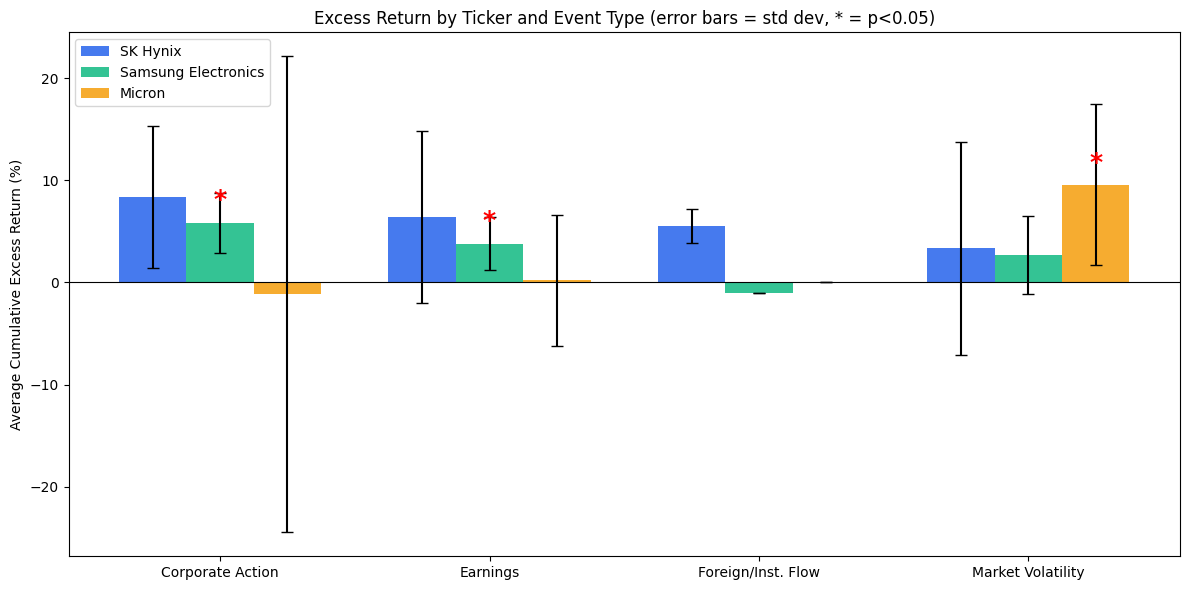

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = final.reset_index()

tickers = plot_data['ticker'].unique()
event_types = ['corporate_action', 'earnings', 'foreign_flow', 'market_volatility']
event_labels = {'corporate_action': 'Corporate Action', 'earnings': 'Earnings',
                 'foreign_flow': 'Foreign/Inst. Flow', 'market_volatility': 'Market Volatility'}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(event_types))
width = 0.25
colors = {'000660': '#2563eb', '005930': '#10b981', 'MU': '#f59e0b'}
labels = {'000660': 'SK Hynix', '005930': 'Samsung Electronics', 'MU': 'Micron'}

for i, ticker in enumerate(tickers):
    subset = plot_data[plot_data['ticker'] == ticker].set_index('event_type')
    means = [subset.loc[et, 'mean'] if et in subset.index else 0 for et in event_types]
    stds = [subset.loc[et, 'std'] if et in subset.index and pd.notna(subset.loc[et, 'std']) else 0 for et in event_types]
    sig = [subset.loc[et, 'significant'] if et in subset.index else False for et in event_types]

    bars = ax.bar(x + i*width, means, width, yerr=stds, capsize=4,
                   label=labels.get(ticker, ticker), color=colors.get(ticker, 'gray'), alpha=0.85)

    for bar, is_sig in zip(bars, sig):
        if is_sig:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                    '*', ha='center', fontsize=18, color='red', fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([event_labels[et] for et in event_types])
ax.set_ylabel('Average Cumulative Excess Return (%)')
ax.set_title('Excess Return by Ticker and Event Type (error bars = std dev, * = p<0.05)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/excess_return_by_type.png', dpi=150)
plt.show()

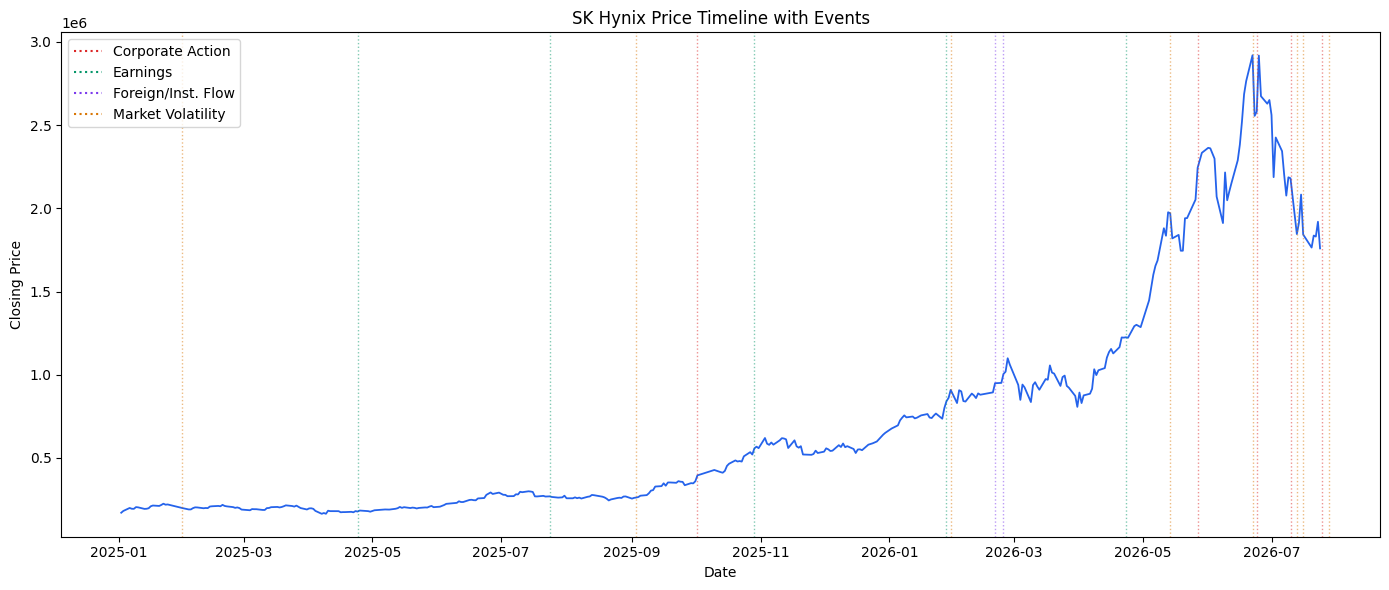

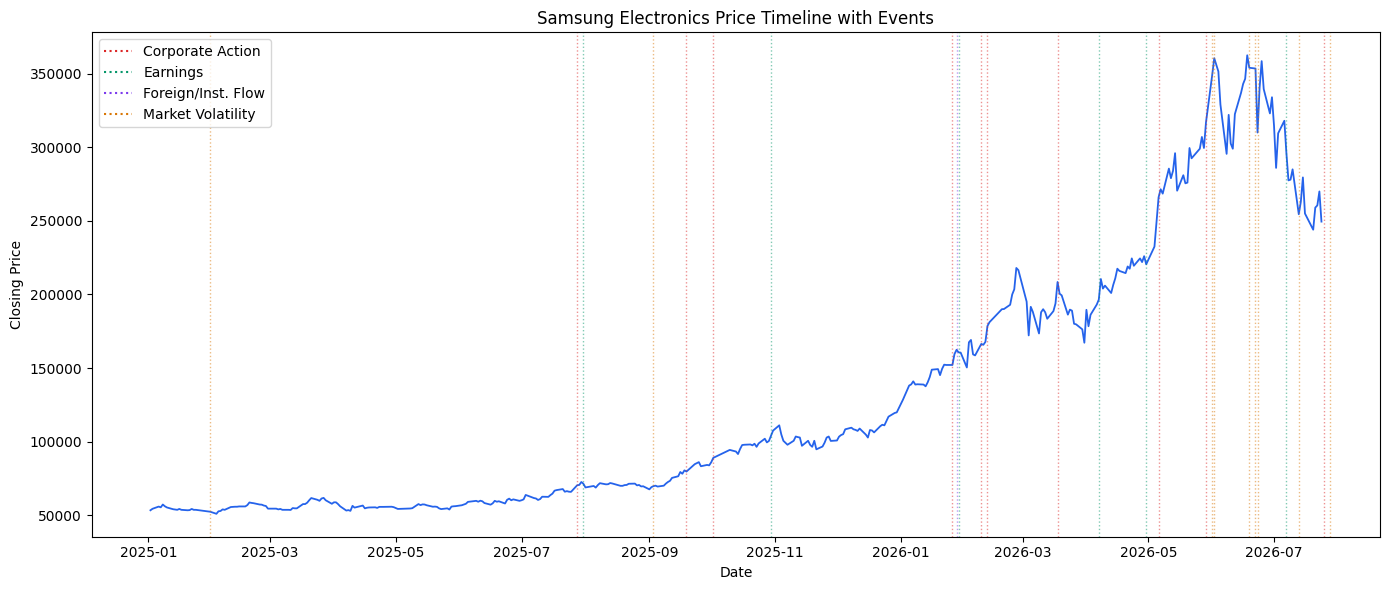

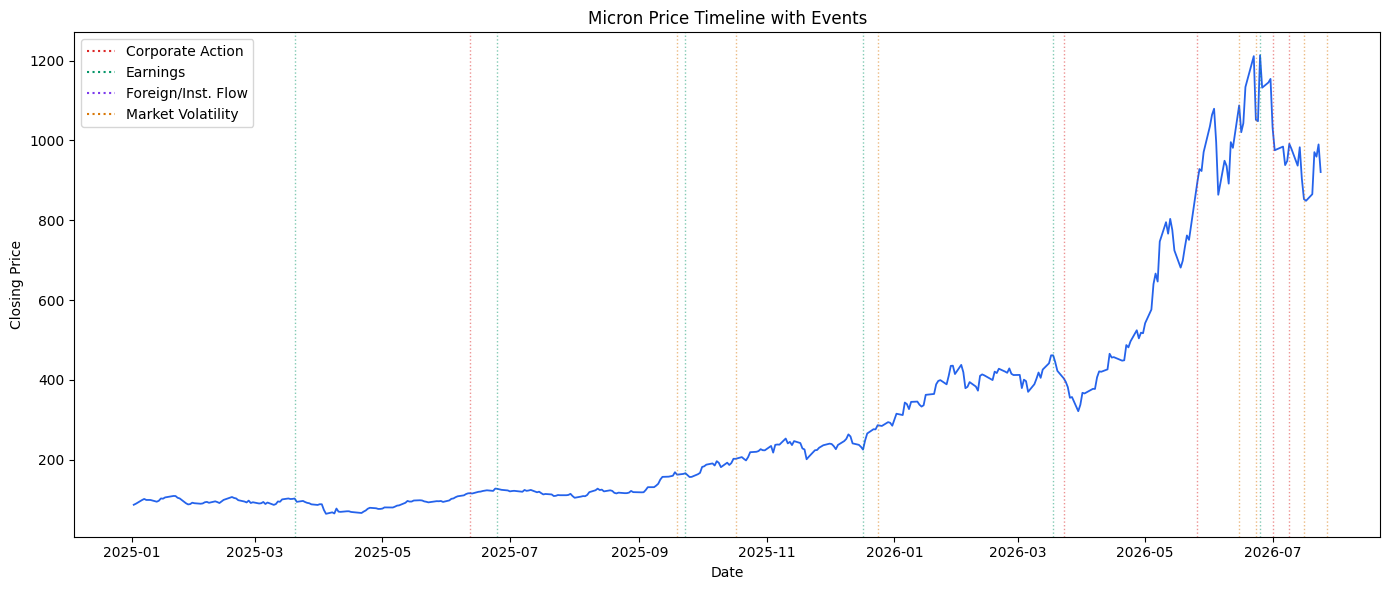

In [13]:
from matplotlib.lines import Line2D

def plot_price_with_events(ticker, ticker_name, price_df, events_df):
    subset_price = price_df[price_df['ticker'] == ticker].sort_values('date')
    subset_events = events_df[events_df['ticker'] == ticker]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(pd.to_datetime(subset_price['date']), subset_price['close'],
            color='#2563eb', linewidth=1.3)

    colors_by_type = {
        'corporate_action': '#dc2626',
        'earnings': '#059669',
        'foreign_flow': '#7c3aed',
        'market_volatility': '#d97706'
    }
    type_labels = {
        'corporate_action': 'Corporate Action',
        'earnings': 'Earnings',
        'foreign_flow': 'Foreign/Inst. Flow',
        'market_volatility': 'Market Volatility'
    }

    for _, ev in subset_events.iterrows():
        ev_date = pd.to_datetime(ev['event_date'])
        color = colors_by_type.get(ev['event_type'], 'gray')
        ax.axvline(ev_date, color=color, linestyle=':', alpha=0.5, linewidth=1)

    ax.set_title(f'{ticker_name} Price Timeline with Events')
    ax.set_ylabel('Closing Price')
    ax.set_xlabel('Date')

    legend_elements = [Line2D([0], [0], color=c, linestyle=':', label=type_labels[k])
                        for k, c in colors_by_type.items()]
    ax.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.savefig(f'../data/processed/timeline_{ticker}.png', dpi=150)
    plt.show()

price_all = pd.read_sql_query("SELECT * FROM daily_price", conn)
events_all = pd.read_sql_query("SELECT * FROM events", conn)

plot_price_with_events('000660', 'SK Hynix', price_all, events_all)
plot_price_with_events('005930', 'Samsung Electronics', price_all, events_all)
plot_price_with_events('MU', 'Micron', price_all, events_all)